In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from tqdm import tqdm
from sklearn.linear_model import LogisticRegression

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
seed = 42
C = np.inf

In [3]:
# make sources
z_01 = np.linspace(0, 1, 32)

# modify density
z_01 = z_01 ** 2

z_01 = np.meshgrid(z_01, z_01)
z_01 = np.stack(z_01, 0).reshape(2, -1).T
z_01 = np.concatenate([z_01, np.zeros_like(z_01[:, :1])], 1)

z_02 = np.stack([z_01[:, 0], z_01[:, 2], z_01[:, 1]], 1)
z_12 = np.stack([z_01[:, 2], z_01[:, 0], z_01[:, 1]], 1)

z_01.shape, z_02.shape, z_12.shape

((1024, 3), (1024, 3), (1024, 3))

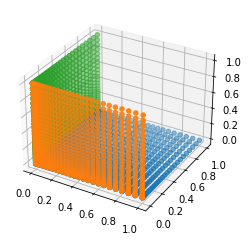

In [4]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(*z_01.T)
ax.scatter(*z_02.T)
ax.scatter(*z_12.T)

In [5]:
# random down projection
np.random.seed(42 + 0)
A = np.random.normal(0, 1, (3, 2))

# nice, clean, down projection
# A = np.array((
#     (1, 0),
#     (np.cos(2*np.pi/3), np.sin(2*np.pi/3)),
#     (np.cos(2*np.pi/3*2), np.sin(2*np.pi/3*2)),
# ))

In [6]:
# train A (linear encoder, nonlinear decoder)
num_seed = 10

inputs = np.concatenate([z_01, z_12, z_02], 0)
inputs = torch.tensor(inputs, dtype=torch.float32, device=device)

best_loss = np.inf
A = None

for rep in range(num_seed):
    torch.manual_seed(seed + rep)
    # MLP gets perfect
    encoder = nn.Linear(3, 2, bias=False).to(device)
    decoder = nn.Sequential(nn.Linear(2, 256), nn.ReLU(), nn.Linear(256, 3)).to(device)
    optim = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=1e-3)

    for i in tqdm(range(10000)):
        y = encoder(inputs)
        rec = decoder(y)
        loss = torch.mean((inputs - rec) **2 )
        optim.zero_grad()
        loss.backward()
        optim.step()
    print(rep, i, loss.item())
    if loss.item() < best_loss:
        best_loss = loss.item()
        A = encoder.weight.detach().cpu().numpy().T
        if best_loss < 1e-4:
            break

100%|██████████| 10000/10000 [00:44<00:00, 224.26it/s]

0 9999 1.448966850148281e-05


In [7]:
A /= np.linalg.norm(A, axis=1, keepdims=True)

In [8]:
# make observations
y_01 = z_01 @ A
y_02 = z_02 @ A
y_12 = z_12 @ A

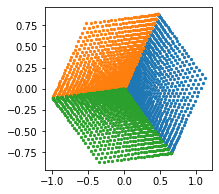

In [9]:
s = 5
plt.figure(figsize=(3, 3))
plt.scatter(*y_01.T, s=s)
plt.scatter(*y_02.T, s=s)
plt.scatter(*y_12.T, s=s)

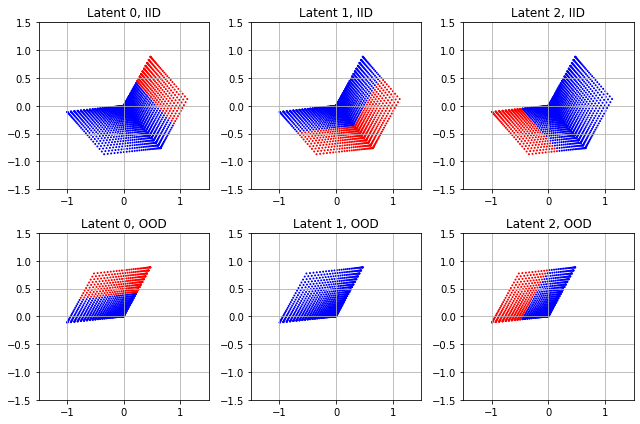

In [10]:
z_iid = np.concatenate([z_01, z_12], 0)
z_ood = z_02
y_iid = z_iid @ A
y_ood = z_ood @ A

label_iid = z_iid > .5
label_ood = z_ood > .5

dum = 1.5
xlim = (-dum, dum)
ylim = (-dum, dum)

s = 1

plt.figure(figsize=(9, 6))
for i in range(3):
    plt.subplot(2, 3, 1 + i)
    plt.scatter(*y_iid.T, c=label_iid[:, i], s=s, cmap='bwr')
    plt.grid()
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.title('Latent %s, IID' % i)
    
    plt.subplot(2, 3, 4 + i)
    plt.scatter(*y_ood.T, c=label_ood[:, i], s=s, cmap='bwr')
    plt.grid()
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.title('Latent %s, OOD' % i)

plt.tight_layout()
plt.show()

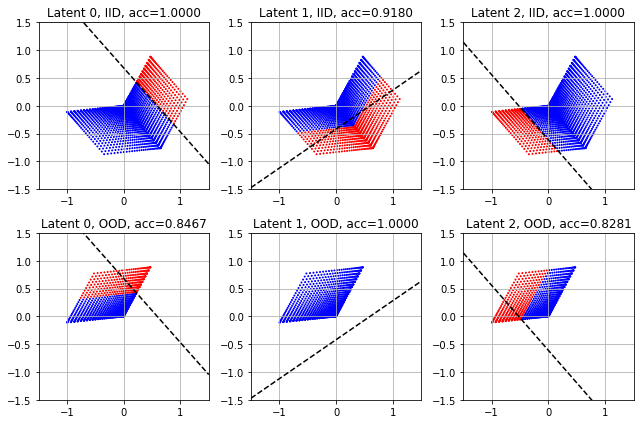

In [11]:
# linear probes
plt.figure(figsize=(9, 6))
for i in range(3):
    # Assume y is shape (N, 2) and label[:, 0] is binary (shape: N,)
    clf = LogisticRegression(C=C).fit(y_iid, label_iid[:, i])
    
    # Extract weights and bias
    w = clf.coef_[0]   # shape (2,)
    b = clf.intercept_[0]
    
    # Decision boundary: w₀ * x + w₁ * y + b = 0 → y = -(w₀/w₁)x - b/w₁
    x_vals = np.linspace(*xlim, 100)
    y_vals = -(w[0] / w[1]) * x_vals - b / w[1]
    
    # Plot data and boundary
    plt.subplot(2, 3, 1 + i)
    plt.scatter(*y_iid.T, c=label_iid[:, i], s=s, cmap='bwr')
    plt.plot(x_vals, y_vals, 'k--', label='Decision boundary')
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.grid()
    plt.title('Latent %s, IID, acc=%.4f' % (
        i, clf.score(y_iid, label_iid[:, i]))
    )
    
    plt.subplot(2, 3, 4 + i)
    plt.scatter(*y_ood.T, c=label_ood[:, i], s=s, cmap='bwr')
    plt.plot(x_vals, y_vals, 'k--', label='Decision boundary')
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.grid()
    plt.title('Latent %s, OOD, acc=%.4f' % (
        i, clf.score(y_ood, label_ood[:, i]))
    )
    
plt.tight_layout()
plt.show()

In [12]:
for ind in range(3):
    clf = LogisticRegression(C=C).fit(z_iid, label_iid[:, ind])
    
    acc_iid = clf.score(z_iid, label_iid[:, ind])
    acc_ood = clf.score(z_ood, label_ood[:, ind])
    print(f'index {ind}, acc IID: {acc_iid:.3f}, acc OOD: {acc_ood:.3f}')

index 0, acc IID: 1.000, acc OOD: 1.000
index 1, acc IID: 1.000, acc OOD: 1.000
index 2, acc IID: 1.000, acc OOD: 1.000


In [13]:
num_seed = 3

target = np.concatenate([z_01, z_12, z_02], 0)
inputs = target @ A
inputs = torch.tensor(inputs, dtype=torch.float32, device=device)
target = torch.tensor(target, dtype=torch.float32, device=device)

best_loss = np.inf
z_ = None

for rep in range(num_seed):
    torch.manual_seed(seed + rep)
    # SAE encoder:
    model = nn.Sequential(nn.Linear(2, 3), nn.Softplus()).to(device)
    # MLP gets perfect
    # model = nn.Sequential(nn.Linear(2, 256), nn.ReLU(), nn.Linear(256, 3)).to(device)
    decoder = nn.Linear(3, 2).to(device)
    optim = torch.optim.Adam(list(model.parameters()) + list(decoder.parameters()), lr=1e-3)

    for i in tqdm(range(10000)):
        pred = model(inputs[:z_01.shape[0] * 2]) # train on iid
        
        # supervised
        mse = torch.mean((target[:z_01.shape[0] * 2] - pred)**2)
        l1 = 0
        loss = mse
        
        # unsup
        # rec = decoder(pred)
        # mse = torch.mean((inputs[:z_01.shape[0] * 2] - rec)**2)
        # l1 = torch.mean(torch.abs(pred) * torch.linalg.norm(decoder.weight, dim=0))
        # loss = mse + 1e-1 * l1
        
        optim.zero_grad()
        loss.backward()
        optim.step()
    print(rep, i, mse.item(), l1)
    if loss.item() < best_loss:
        best_loss = loss.item()
        pred = model(inputs) # predict all
        z_ = pred.detach().cpu().numpy()

100%|██████████| 10000/10000 [00:03<00:00, 2691.36it/s]


0 9999 0.009368072263896465 0


100%|██████████| 10000/10000 [00:03<00:00, 2686.19it/s]


1 9999 0.009366990067064762 0


100%|██████████| 10000/10000 [00:03<00:00, 2686.61it/s]

2 9999 0.009370054118335247 0


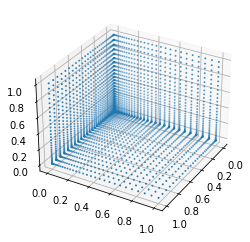

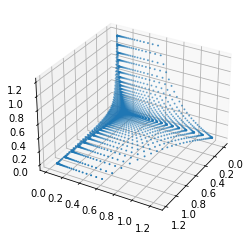

In [16]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(*target.detach().cpu().numpy().T, s=s)
elev = 30
azim = 30
roll = 0
ax.view_init(elev, azim)
# ax.view_init(elev, azim, roll)

plt.show()

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(*z_.T, s=s)
ax.view_init(elev, azim)
plt.show()

In [17]:
z_iid_sc = z_[:z_01.shape[0] * 2]
z_ood_sc = z_[z_01.shape[0] * 2:]

for ind in range(3):
    clf = LogisticRegression(C=C).fit(z_iid_sc, label_iid[:, ind])
    
    acc_iid = clf.score(z_iid_sc, label_iid[:, ind])
    acc_ood = clf.score(z_ood_sc, label_ood[:, ind])
    print(f'index {ind}, acc IID: {acc_iid:.3f}, acc OOD: {acc_ood:.3f}')

index 0, acc IID: 1.000, acc OOD: 0.845
index 1, acc IID: 0.962, acc OOD: 1.000
index 2, acc IID: 1.000, acc OOD: 0.826


In [18]:
from sklearn.decomposition import DictionaryLearning
from sklearn.decomposition import sparse_encode

target = np.concatenate([z_01, z_12, z_02], 0)
inputs = target @ A

X_transformed = sparse_encode(inputs, A, algorithm='lasso_cd', alpha=0, positive=True)

X_transformed.shape, X_transformed.min()

/Users/vitoria/miniconda3/envs/research/lib/python3.9/site-packages/sklearn/decomposition/_dict_learning.py:157: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  clf.fit(dictionary.T, X.T, check_input=check_input)
/Users/vitoria/miniconda3/envs/research/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:526: UserWarning: Coordinate descent with alpha=0 may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent_gram(
/Users/vitoria/miniconda3/envs/research/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:526: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.0, tolerance: 0.0
  model = cd_fast.enet_coordinate_descent_gram(


((3072, 3), 0.0)

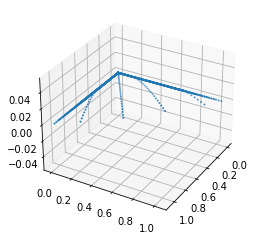

In [39]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(*X_transformed.T, s=s)
ax.view_init(elev, azim)
plt.show()

In [20]:
z_iid_sc = X_transformed[:z_01.shape[0] * 2]
z_ood_sc = X_transformed[z_01.shape[0] * 2:]

for ind in range(3):
    clf = LogisticRegression(C=C).fit(z_iid_sc, label_iid[:, ind])
    
    acc_iid = clf.score(z_iid_sc, label_iid[:, ind])
    acc_ood = clf.score(z_ood_sc, label_ood[:, ind])
    print(f'index {ind}, acc IID: {acc_iid:.3f}, acc OOD: {acc_ood:.3f}')

for ind in range(3):
    for j in range(3):
        clf = LogisticRegression(C=C).fit(z_iid_sc[:, j][:, None], label_iid[:, ind])
        
        acc_iid = clf.score(z_iid_sc[:, j][:, None], label_iid[:, ind])
        acc_ood = clf.score(z_ood_sc[:, j][:, None], label_ood[:, ind])
        print(j, f'index {ind}, acc IID: {acc_iid:.3f}, acc OOD: {acc_ood:.3f}')

index 0, acc IID: 1.000, acc OOD: 1.000
index 1, acc IID: 1.000, acc OOD: 1.000
index 2, acc IID: 1.000, acc OOD: 1.000
0 index 0, acc IID: 1.000, acc OOD: 1.000
1 index 0, acc IID: 0.844, acc OOD: 0.688
2 index 0, acc IID: 0.844, acc OOD: 0.688
0 index 1, acc IID: 0.688, acc OOD: 1.000
1 index 1, acc IID: 1.000, acc OOD: 1.000
2 index 1, acc IID: 0.688, acc OOD: 1.000
0 index 2, acc IID: 0.844, acc OOD: 0.688
1 index 2, acc IID: 0.844, acc OOD: 0.688
2 index 2, acc IID: 1.000, acc OOD: 1.000


In [21]:
dict_learner = DictionaryLearning(
    n_components=3, 
    fit_algorithm='cd',
    transform_algorithm='lasso_cd', 
    transform_max_iter=100000,  # default is 1000
    transform_alpha=1e-6,
    random_state=42,
    verbose=True,
    positive_code=True,
    # tol=1e-9
)
X_transformed = dict_learner.fit_transform(inputs)

[dict_learning] .+.

/Users/vitoria/miniconda3/envs/research/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:526: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.0, tolerance: 0.0
  model = cd_fast.enet_coordinate_descent_gram(
/Users/vitoria/miniconda3/envs/research/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:526: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.0, tolerance: 0.0
  model = cd_fast.enet_coordinate_descent_gram(


++.++.

/Users/vitoria/miniconda3/envs/research/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:526: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.0, tolerance: 0.0
  model = cd_fast.enet_coordinate_descent_gram(
/Users/vitoria/miniconda3/envs/research/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:526: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.0, tolerance: 0.0
  model = cd_fast.enet_coordinate_descent_gram(


+.+.

...

..

/Users/vitoria/miniconda3/envs/research/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:526: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.0, tolerance: 0.0
  model = cd_fast.enet_coordinate_descent_gram(
/Users/vitoria/miniconda3/envs/research/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:526: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.0, tolerance: 0.0
  model = cd_fast.enet_coordinate_descent_gram(


..

/Users/vitoria/miniconda3/envs/research/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:526: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.0, tolerance: 0.0
  model = cd_fast.enet_coordinate_descent_gram(
/Users/vitoria/miniconda3/envs/research/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:526: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.0, tolerance: 0.0
  model = cd_fast.enet_coordinate_descent_gram(


/Users/vitoria/miniconda3/envs/research/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:526: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.0, tolerance: 0.0
  model = cd_fast.enet_coordinate_descent_gram(


In [22]:
X_transformed.max()

1.061484054328757

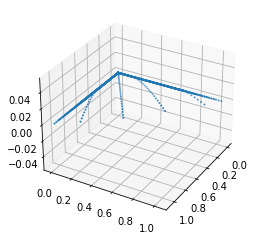

In [32]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(*X_transformed.T, s=s)
ax.view_init(elev, azim)
plt.show()

In [33]:
z_iid_sc = X_transformed[:z_01.shape[0] * 2]
z_ood_sc = X_transformed[z_01.shape[0] * 2:]

for ind in range(3):
    clf = LogisticRegression(C=C).fit(z_iid_sc, label_iid[:, ind])
    
    acc_iid = clf.score(z_iid_sc, label_iid[:, ind])
    acc_ood = clf.score(z_ood_sc, label_ood[:, ind])
    print(f'index {ind}, acc IID: {acc_iid:.3f}, acc OOD: {acc_ood:.3f}')

index 0, acc IID: 0.974, acc OOD: 0.772
index 1, acc IID: 0.857, acc OOD: 1.000
index 2, acc IID: 0.844, acc OOD: 0.688


  0%|          | 0/100000 [00:00<?, ?it/s]

0 0 3.5570127964019775 1.0277029275894165


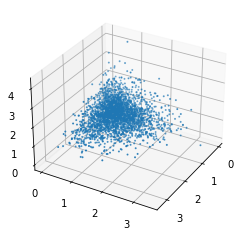

 10%|▉         | 9975/100000 [00:07<01:02, 1449.75it/s]

0 10000 2.793938165268628e-07 0.33065325021743774


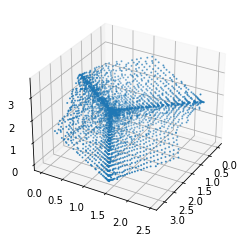

 20%|█▉        | 19937/100000 [00:13<00:53, 1486.75it/s]

0 20000 3.032784832157631e-07 0.2272370457649231


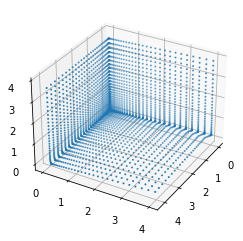

 30%|██▉       | 29953/100000 [00:20<00:47, 1481.40it/s]

0 30000 2.3041532415390975e-07 0.2255708873271942


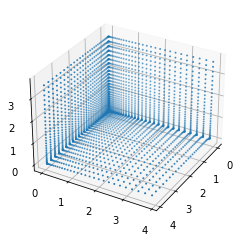

 40%|███▉      | 39887/100000 [00:28<00:46, 1292.81it/s]

0 40000 7.882934482950077e-07 0.2254067063331604


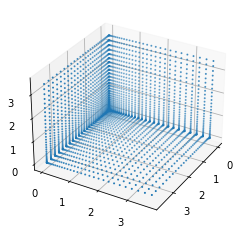

 50%|████▉     | 49918/100000 [00:35<00:34, 1465.64it/s]

0 50000 1.527183485450223e-06 0.22534526884555817


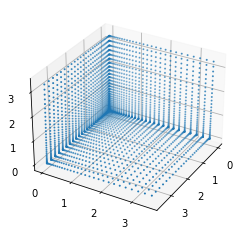

 60%|█████▉    | 59912/100000 [00:42<00:37, 1076.08it/s]

0 60000 8.48610852699494e-07 0.22533822059631348


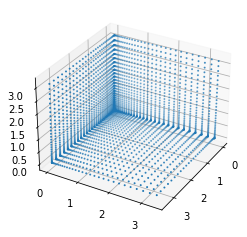

 70%|██████▉   | 69963/100000 [00:50<00:20, 1452.23it/s]

0 70000 6.963232976886502e-07 0.22534476220607758


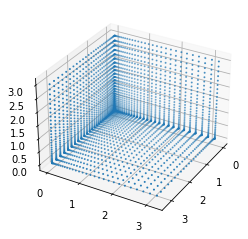

 80%|███████▉  | 79996/100000 [00:57<00:13, 1492.49it/s]

0 80000 2.2304364222236472e-07 0.22531986236572266


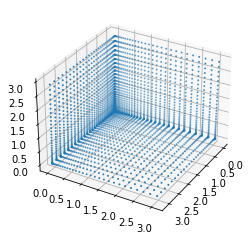

 90%|████████▉ | 89882/100000 [01:04<00:06, 1497.89it/s]

0 90000 2.71137679419553e-07 0.2253081500530243


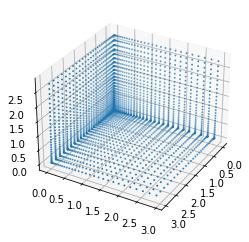

100%|██████████| 100000/100000 [01:10<00:00, 1409.70it/s]


0 99999 2.899861613059329e-07 0.22531181573867798


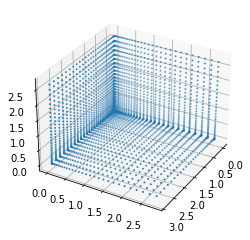

In [35]:
num_seed = 1

target = np.concatenate([z_01, z_12, z_02], 0)
inputs = target @ A
inputs = torch.tensor(inputs, dtype=torch.float32, device=device)
target = torch.tensor(target, dtype=torch.float32, device=device)

best_loss = np.inf
best_D, best_Z = None, None

for rep in range(num_seed):
    torch.manual_seed(seed + rep)

    log_Z = torch.randn(inputs.shape[0], 3, device=device).requires_grad_()
    D = torch.randn(3, 2, device=device).requires_grad_()
    # D = torch.tensor(A, dtype=torch.float32, device=device)
    optim = torch.optim.Adam([log_Z, D], lr=1e-2)

    for i in tqdm(range(100000)):
        # Z = torch.exp(log_Z)
        Z = torch.nn.functional.softplus(log_Z)
        # Z = torch.nn.functional.relu(log_Z)
        # Z = torch.nn.functional.gelu(log_Z)
        rec = Z @ D
        mse = torch.mean((inputs - rec)**2)
        # l1 = torch.mean(Z)
        l1 = torch.mean(torch.abs(Z) * torch.linalg.norm(D, dim=1))
        loss = mse + 0.001 * l1
        optim.zero_grad()
        loss.backward()
        optim.step()

        # D.data /= torch.linalg.norm(D, dim=1, keepdim=True)
        
        if rep == 0 and not i % 10000:
            print(rep, i, mse.item(), l1.item())
            fig = plt.figure()
            ax = fig.add_subplot(projection='3d')
            ax.scatter(*Z.detach().cpu().numpy().T, s=s)
            ax.view_init(elev, azim)
            plt.show()

        if i > 10000:
            if loss.item() > best_loss * 1.1:
                break
    print(rep, i, mse.item(), l1.item())
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    ax.scatter(*Z.detach().cpu().numpy().T, s=s)
    ax.view_init(elev, azim)
    plt.show()
    if loss.item() < best_loss:
        best_D = D.detach().cpu().numpy()
        best_Z = Z.detach().cpu().numpy()

In [26]:
best_Z = Z.detach().cpu().numpy()

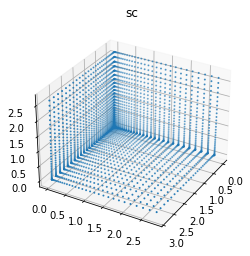

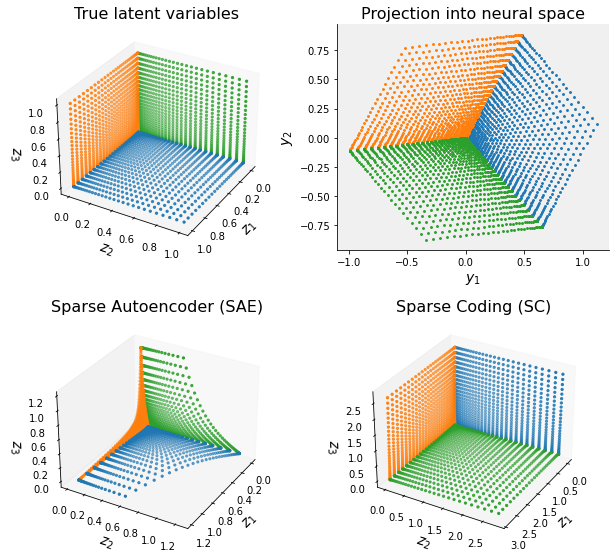

In [93]:
fig = plt.figure(figsize=(10, 9))

# Set viewing angles
elev = 30
azim = 30

# Define consistent colors for the three groups
colors = ['tab:blue', 'tab:orange', 'tab:green']

# Subplot 1: True data (3D)
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
target_data = target.detach().cpu().numpy()
# Split data into the three groups (same order as concatenation: z_01, z_12, z_02)
n_points = z_01.shape[0]
ax1.scatter(*target_data[:n_points].T, s=s, color=colors[0], label='z_01')
ax1.scatter(*target_data[n_points:2*n_points].T, s=s, color=colors[2], label='z_12')
ax1.scatter(*target_data[2*n_points:].T, s=s, color=colors[1], label='z_02')
ax1.view_init(elev, azim)
ax1.set_title('True latent variables', fontsize=16)
ax1.grid(False)
ax1.set_xlabel('$z_1$', fontsize=14)
ax1.set_ylabel('$z_2$', fontsize=14)
ax1.set_zlabel('$z_3$', fontsize=14)
ax1.tick_params(axis='both', which='major', labelsize=10)

# Subplot 2: 2D projection data
ax2 = fig.add_subplot(2, 2, 2)
ax2.scatter(*y_01.T, s=s*0.7, color=colors[0], label='z_01')
ax2.scatter(*y_02.T, s=s*0.7, color=colors[1], label='z_02')
ax2.scatter(*y_12.T, s=s*0.7, color=colors[2], label='z_12')
ax2.set_title('Projection into neural space', fontsize=16)
ax2.set_aspect('equal', adjustable='box')
ax2.set_xlabel('$y_1$', fontsize=14)
ax2.set_ylabel('$y_2$', fontsize=14)
ax2.tick_params(axis='both', which='major', labelsize=10)
# Remove top and right spines to match 3D plot aesthetic
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
# Set background color to match 3D plots
ax2.set_facecolor('#f0f0f0')

# Subplot 3: SAE data (3D)
ax3 = fig.add_subplot(2, 2, 3, projection='3d')
# Split SAE data into the three groups
ax3.scatter(*z_[:n_points].T, s=s, color=colors[0], label='z_01')
ax3.scatter(*z_[n_points:2*n_points].T, s=s, color=colors[2], label='z_12')
ax3.scatter(*z_[2*n_points:].T, s=s, color=colors[1], label='z_02')
ax3.view_init(elev, azim)
ax3.set_title('Sparse Autoencoder (SAE)', fontsize=16)
ax3.grid(False)
ax3.set_xlabel('$z_1$', fontsize=14)
ax3.set_ylabel('$z_2$', fontsize=14)
ax3.set_zlabel('$z_3$', fontsize=14)
ax3.tick_params(axis='both', which='major', labelsize=10)

# Subplot 4: Sparse Coding data (3D)
ax4 = fig.add_subplot(2, 2, 4, projection='3d')
# Split Sparse Coding data into the three groups
ax4.scatter(*best_Z[:n_points].T, s=s, color=colors[0], label='z_01')
ax4.scatter(*best_Z[n_points:2*n_points].T, s=s, color=colors[2], label='z_12')
ax4.scatter(*best_Z[2*n_points:].T, s=s, color=colors[1], label='z_02')
ax4.view_init(elev, azim)
ax4.set_title('Sparse Coding (SC)', fontsize=16)
ax4.grid(False)
ax4.set_xlabel('$z_1$', fontsize=14)
ax4.set_ylabel('$z_2$', fontsize=14)
ax4.set_zlabel('$z_3$', fontsize=14)
ax4.tick_params(axis='both', which='major', labelsize=10)

# Tight layout with minimal spacing
plt.subplots_adjust(left=0.08, right=0.95, bottom=0.1, top=0.9, hspace=0.3, wspace=0.02)
plt.savefig('toy.pdf')

In [29]:
z_iid_sc = best_Z[:z_01.shape[0] * 2]
z_ood_sc = best_Z[z_01.shape[0] * 2:]

for ind in range(3):
    clf = LogisticRegression(C=C).fit(z_iid_sc, label_iid[:, ind])
    
    acc_iid = clf.score(z_iid_sc, label_iid[:, ind])
    acc_ood = clf.score(z_ood_sc, label_ood[:, ind])
    print(f'index {ind}, acc IID: {acc_iid:.3f}, acc OOD: {acc_ood:.3f}')

index 0, acc IID: 0.844, acc OOD: 0.688
index 1, acc IID: 0.688, acc OOD: 0.999
index 2, acc IID: 0.844, acc OOD: 0.688


In [30]:
torch.linalg.norm(D, dim=1), np.max(best_Z, 0)

(tensor([1.0568, 1.9717, 0.7626], grad_fn=<CopyBackwards>),
 array([3.2862847, 3.4770124, 4.235464 ], dtype=float32))

In [31]:
z_iid_sc = best_Z[:z_01.shape[0] * 2]
z_ood_sc = best_Z[z_01.shape[0] * 2:]

for ind in range(3):
    for j in range(3):
        clf = LogisticRegression(C=C).fit(z_iid_sc[:, j][:, None], label_iid[:, ind])
        
        acc_iid = clf.score(z_iid_sc[:, j][:, None], label_iid[:, ind])
        acc_ood = clf.score(z_ood_sc[:, j][:, None], label_ood[:, ind])
        print(j, f'index {ind}, acc IID: {acc_iid:.3f}, acc OOD: {acc_ood:.3f}')

0 index 0, acc IID: 0.844, acc OOD: 0.688
1 index 0, acc IID: 0.844, acc OOD: 0.688
2 index 0, acc IID: 0.844, acc OOD: 0.688
0 index 1, acc IID: 0.688, acc OOD: 1.000
1 index 1, acc IID: 0.688, acc OOD: 1.000
2 index 1, acc IID: 0.688, acc OOD: 0.999
0 index 2, acc IID: 0.844, acc OOD: 0.688
1 index 2, acc IID: 0.844, acc OOD: 0.688
2 index 2, acc IID: 0.844, acc OOD: 0.688


In [135]:
import sys
sys.path.append('/grid/klindt/home/klindt/sparsecoding')

from sparsecoding import inference
from sparsecoding import models

In [139]:
# Only inference first: LCA
lca = inference.LCA(
    coeff_lr=1e-3,
    threshold=0.1,
    n_iter=10000,
    nonnegative=True
)

with torch.no_grad():
    z = lca.infer(
        torch.tensor(inputs, dtype=torch.float32, device=device),
        torch.tensor(A.T, dtype=torch.float32, device=device)
    ).detach().cpu().numpy()
rec = z @ A
rec.shape

/tmp/11985082.1.gpu_ded.q/ipykernel_3042018/2390266861.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(inputs, dtype=torch.float32, device=device),


(3072, 2)

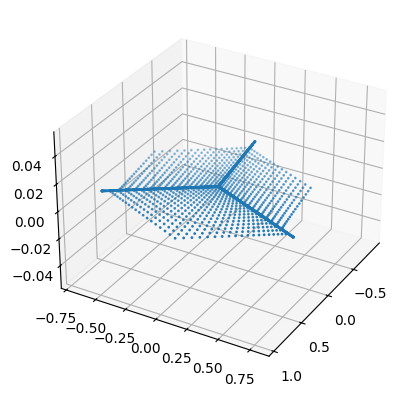

In [140]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(*rec.T, s=s)
ax.view_init(elev, azim, roll)
plt.show()

In [138]:
z_iid_sc = rec[:z_01.shape[0] * 2]
z_ood_sc = rec[z_01.shape[0] * 2:]

for ind in range(3):
    clf = LogisticRegression(C=C).fit(z_iid_sc, label_iid[:, ind])
    
    acc_iid = clf.score(z_iid_sc, label_iid[:, ind])
    acc_ood = clf.score(z_ood_sc, label_ood[:, ind])
    print(f'index {ind}, acc IID: {acc_iid:.3f}, acc OOD: {acc_ood:.3f}')

index 0, acc IID: 1.000, acc OOD: 0.849
index 1, acc IID: 0.918, acc OOD: 1.000
index 2, acc IID: 1.000, acc OOD: 0.835
